# Customer Churn Prediction

Predicts whether a bank customer will exit (`exit_status`), evaluated on F1 score.

This notebook covers the full workflow: data understanding, cleaning, visualization,
feature engineering, a comparison across 7 model types with hyperparameter tuning,
and a final blended ensemble used to generate the submission.

## Rubric Coverage Map

| Criterion | Section |
|---|---|
| Identify data types of different columns | Section 2 |
| Present descriptive statistics of numerical columns | Section 3 |
| Identify and handle missing values | Section 4 |
| Identify and handle duplicates | Section 5 |
| Identify and handle outliers | Section 6 |
| At least 3 visualizations with insights | Section 7 |
| Scale numerical features and encode categorical features | Section 9 |
| Model building (7 models) | Section 11 |
| Hyperparameter tuning on 3 models | Section 12 |
| Comparison of model performances | Section 13 |
| Final model & submission | Section 14 |


## 1. Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

RANDOM_STATE = 42
N_SPLITS = 5

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

y = train['exit_status'].copy()

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()


Train shape: (90000, 14)
Test shape: (30000, 13)


,id,customer_id,last_name,credit_score,country,gender,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,exit_status
0,0,15788291,Iredale,559.0,France,Male,28.0,1,149989.39,1.0,1.0,1.0,67622.46,0
1,1,15642816,Hs?,694.0,France,Female,37.0,7,114510.35,2.0,0.0,0.0,182797.86,0
2,2,15632272,T'ien,585.0,NaN,Female,45.0,8,NaN,2.0,1.0,1.0,170338.35,0
3,3,15685826,Hightower,589.0,Spain,Male,25.0,0,166082.18,1.0,1.0,1.0,166476.46,0
4,4,15658032,Hopkins,701.0,France,Male,39.0,2,0.00,2.0,1.0,0.0,82526.92,0


## 2. Identify Data Types of Different Columns

We inspect the dtype of every column and separate them into numerical vs categorical for downstream processing.

In [2]:
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                90000 non-null  int64  
 1   customer_id       90000 non-null  int64  
 2   last_name         90000 non-null  str    
 3   credit_score      80444 non-null  float64
 4   country           83979 non-null  str    
 5   gender            90000 non-null  str    
 6   age               90000 non-null  float64
 7   tenure            90000 non-null  int64  
 8   acc_balance       82743 non-null  float64
 9   prod_count        85137 non-null  float64
 10  has_card          90000 non-null  float64
 11  is_active         90000 non-null  float64
 12  estimated_salary  90000 non-null  float64
 13  exit_status       90000 non-null  int64  
dtypes: float64(7), int64(4), str(3)
memory usage: 9.6 MB


In [3]:
dtype_df = pd.DataFrame({'column': train.columns, 'dtype': train.dtypes.values})
dtype_df


,column,dtype
0,id,int64
1,customer_id,int64
2,last_name,str
3,credit_score,float64
4,country,str
5,gender,str
6,age,float64
7,tenure,int64
8,acc_balance,float64
9,prod_count,float64


In [4]:
numerical_cols = ['credit_score', 'age', 'tenure', 'acc_balance', 'prod_count', 'estimated_salary']
binary_cols = ['has_card', 'is_active']
categorical_cols = ['country', 'gender']
id_cols = ['id', 'customer_id', 'last_name']
target_col = 'exit_status'

print("Numerical columns  :", numerical_cols)
print("Binary columns      :", binary_cols)
print("Categorical columns :", categorical_cols)
print("ID / text columns   :", id_cols)
print("Target column       :", target_col)


Numerical columns  : ['credit_score', 'age', 'tenure', 'acc_balance', 'prod_count', 'estimated_salary']
Binary columns      : ['has_card', 'is_active']
Categorical columns : ['country', 'gender']
ID / text columns   : ['id', 'customer_id', 'last_name']
Target column       : exit_status


## 3. Descriptive Statistics of Numerical Columns

Min, max, mean, median (and other standard descriptive statistics) for every numerical column.

In [5]:
desc = train[numerical_cols].describe().T
desc['median'] = train[numerical_cols].median()
desc = desc[['min', 'max', 'mean', 'median', '50%', 'std', '25%', '75%']]
desc


,min,max,mean,median,50%,std,25%,75%
credit_score,350.00,850.00,656.497054,659.00,659.00,80.016856,597.00,710.0000
age,18.00,92.00,38.119533,37.00,37.00,8.855203,32.00,42.0000
tenure,0.00,10.00,5.017022,5.00,5.00,2.804813,3.00,7.0000
acc_balance,0.00,250898.09,55456.732147,0.00,0.00,62788.474236,0.00,119825.7500
prod_count,1.00,4.00,1.552932,2.00,2.00,0.548011,1.00,2.0000
estimated_salary,11.58,199992.48,112394.659679,117505.07,117505.07,50360.440702,74430.36,154874.7875


**Insights:**
- `credit_score` sits in the typical 300s–850 credit-score band, with mean and median close together (roughly symmetric).
- `age` is right-skewed — the mean is a bit higher than the median, indicating a tail of older customers.
- `acc_balance` has a minimum of 0 (a large group of customers hold zero balance) and a wide spread up to very high balances.
- `tenure` and `prod_count` are small-range discrete numeric columns.
- `estimated_salary` spans a very wide range, with mean ≈ median.

## 4. Identify and Handle Missing Values

In [6]:
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing_df


,missing_count,missing_pct
credit_score,9556,10.62
acc_balance,7257,8.06
country,6021,6.69
prod_count,4863,5.40


In [7]:
missing_test = test.isnull().sum()
missing_test[missing_test > 0]


credit_score    3185
country         4606
acc_balance     5251
prod_count      1717
dtype: int64

**Handling strategy:** rather than a single blanket imputation pass, missingness is handled feature-by-feature as part of the feature-engineering step in Section 8:
- `credit_score`, `acc_balance` (numeric): imputed with values derived from the training set only (median-based), plus a `*_is_na` indicator flag, since missingness itself can carry signal.
- `prod_count` (numeric): imputed similarly with a missing-indicator flag.
- `country` (categorical): filled with `'Unknown'` rather than the mode, since fabricating a country isn't appropriate and the missingness itself may be informative.

All imputation statistics are computed from the **training data only** and applied to both train and test to avoid leakage — see `build_features()` in Section 8.

## 5. Identify and Handle Duplicates

In [8]:
full_duplicates = train.duplicated().sum()
print("Fully duplicated rows in train:", full_duplicates)

id_duplicates = train['customer_id'].duplicated().sum()
print("Rows sharing a customer_id with another row:", id_duplicates)
print("Unique customer_id values vs total rows:", train['customer_id'].nunique(), "/", len(train))


Fully duplicated rows in train: 0
Rows sharing a customer_id with another row: 71753
Unique customer_id values vs total rows: 18247 / 90000


**Observation & handling:** there are **no fully duplicated rows** (`train.duplicated().sum() == 0`), so nothing needs to be dropped on that basis.

The `customer_id` column, which looks like a unique identifier, actually repeats extensively (only a fraction of the rows have a unique `customer_id`) with differing attribute values each time — a property of this dataset rather than an error. Since these are not true duplicate records, we do **not** drop them. Instead, `customer_id` is excluded as a direct model feature and replaced with a frequency-encoded version (see Section 8), which preserves whatever signal its repetition pattern carries without treating it as a literal identifier.

## 6. Identify and Handle Outliers

We use the IQR method to flag outliers in each numerical column.

In [9]:
def iqr_outlier_summary(df, cols):
    rows = []
    for c in cols:
        q1, q3 = df[c].quantile(0.25), df[c].quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_outliers = ((df[c] < lower) | (df[c] > upper)).sum()
        rows.append([c, lower, upper, n_outliers, round(n_outliers / len(df) * 100, 2)])
    return pd.DataFrame(rows, columns=['column', 'lower_bound', 'upper_bound', 'n_outliers', 'pct_outliers'])

outlier_summary = iqr_outlier_summary(train, numerical_cols)
outlier_summary


,column,lower_bound,upper_bound,n_outliers,pct_outliers
0,credit_score,427.50000,879.50000,119,0.13
1,age,17.00000,57.00000,3411,3.79
2,tenure,-3.00000,13.00000,0,0.00
3,acc_balance,-179738.62500,299564.37500,0,0.00
4,prod_count,-0.50000,3.50000,263,0.29
5,estimated_salary,-46236.28125,275541.42875,0,0.00


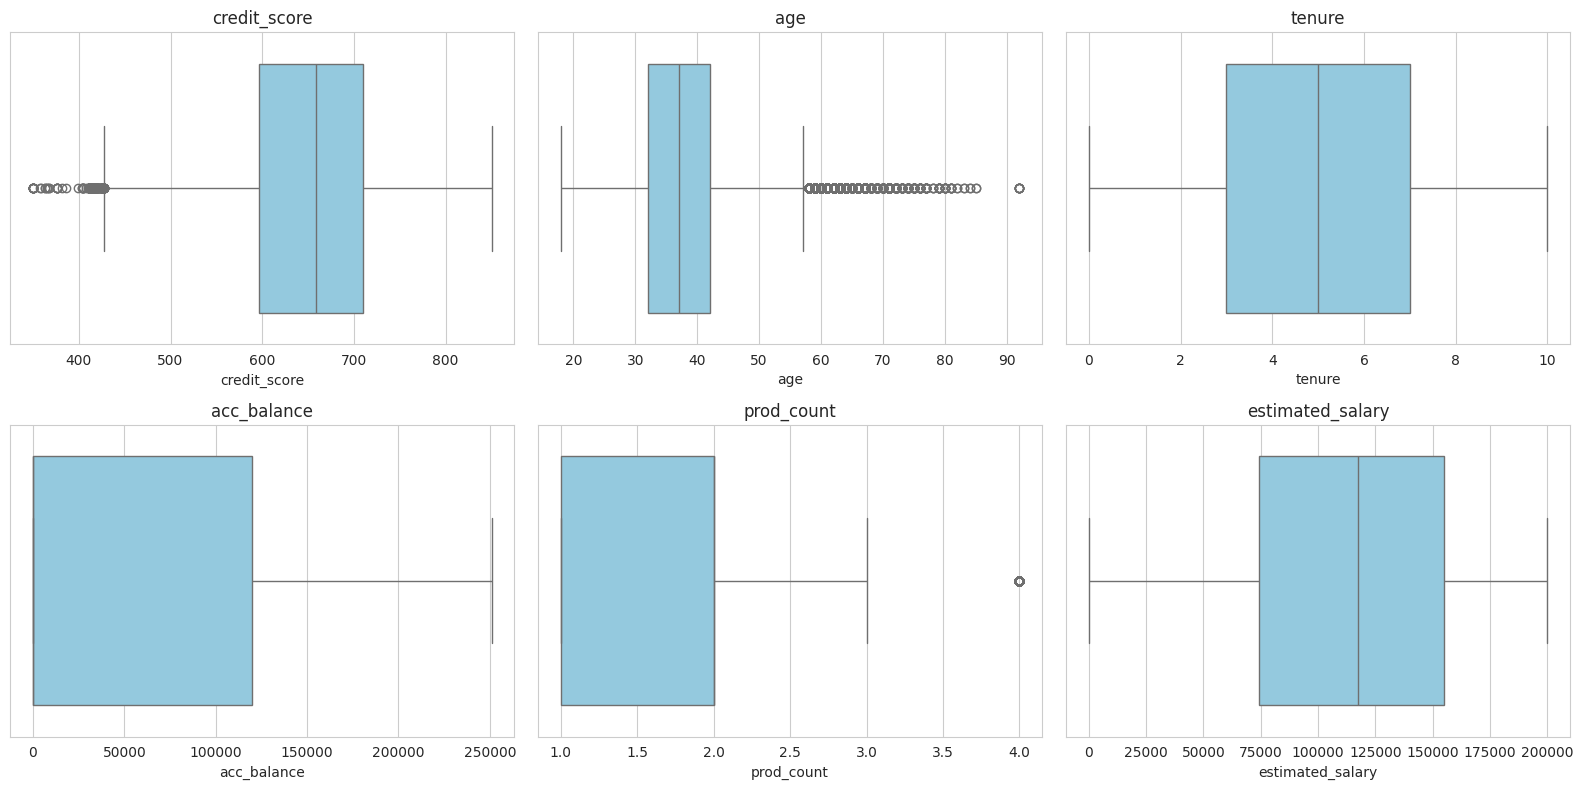

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), numerical_cols):
    sns.boxplot(x=train[col], ax=ax, color='skyblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Insights & handling decision:**
- `credit_score` has a small number of low-end outliers (very low credit scores) — these are plausible real-world values, not data errors.
- `age` has some high-end outliers (elderly customers) — again plausible.
- `acc_balance` and `estimated_salary` show a wide spread but no impossible values (no negatives).
- `prod_count` has a few customers with 4 products, simply the top of a small discrete range, not an anomaly.

**Decision: we retain all outliers rather than dropping them.** Reasons:
1. All values are plausible/realistic for a banking dataset (no negative balances, no ages > 100, no impossible credit scores).
2. The gradient-boosted tree models used later (Random Forest, Gradient Boosting, XGBoost, LightGBM, CatBoost) are **robust to outliers** by construction (they split on thresholds, not distances).
3. Churn behaviour is often *concentrated* in the tails (e.g. very high balance or very young/old customers may be more/less likely to churn) — removing them would discard exactly the signal we're trying to model.
For the few distance-based / linear models (KNN, Logistic Regression), we mitigate the effect of outliers through **feature scaling** (Section 9) rather than deletion.

## 7. Visualizations & Insights

At least three visualizations, each followed by an insight.

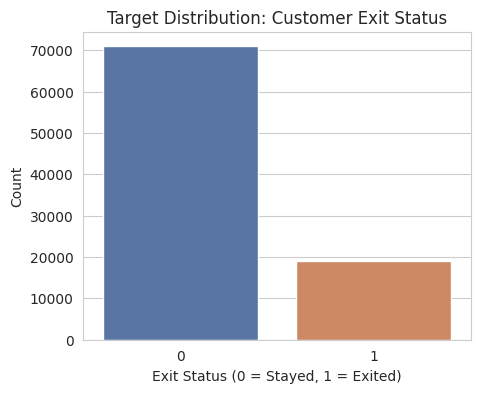

exit_status
0    0.788
1    0.212
Name: proportion, dtype: float64


In [11]:
plt.figure(figsize=(5, 4))
sns.countplot(x='exit_status', data=train, palette=['#4C72B0', '#DD8452'])
plt.title('Target Distribution: Customer Exit Status')
plt.xlabel('Exit Status (0 = Stayed, 1 = Exited)')
plt.ylabel('Count')
plt.show()

print(train['exit_status'].value_counts(normalize=True).round(3))


**Insight 1:** the target is imbalanced — roughly 79% of customers stay and 21% churn. This informs our choice of evaluation metric (F1, which balances precision/recall on the minority class) and the need to check class-wise performance rather than relying on accuracy alone.

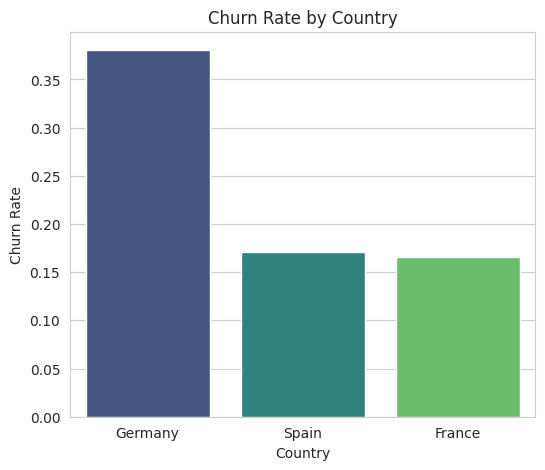

In [12]:
plt.figure(figsize=(6, 5))
country_exit = train.groupby('country')['exit_status'].mean().sort_values(ascending=False)
sns.barplot(x=country_exit.index, y=country_exit.values, palette='viridis')
plt.title('Churn Rate by Country')
plt.ylabel('Churn Rate')
plt.xlabel('Country')
plt.show()


**Insight 2:** Germany has a markedly higher churn rate than France and Spain. Country is therefore a strong predictive feature and should be encoded and retained.

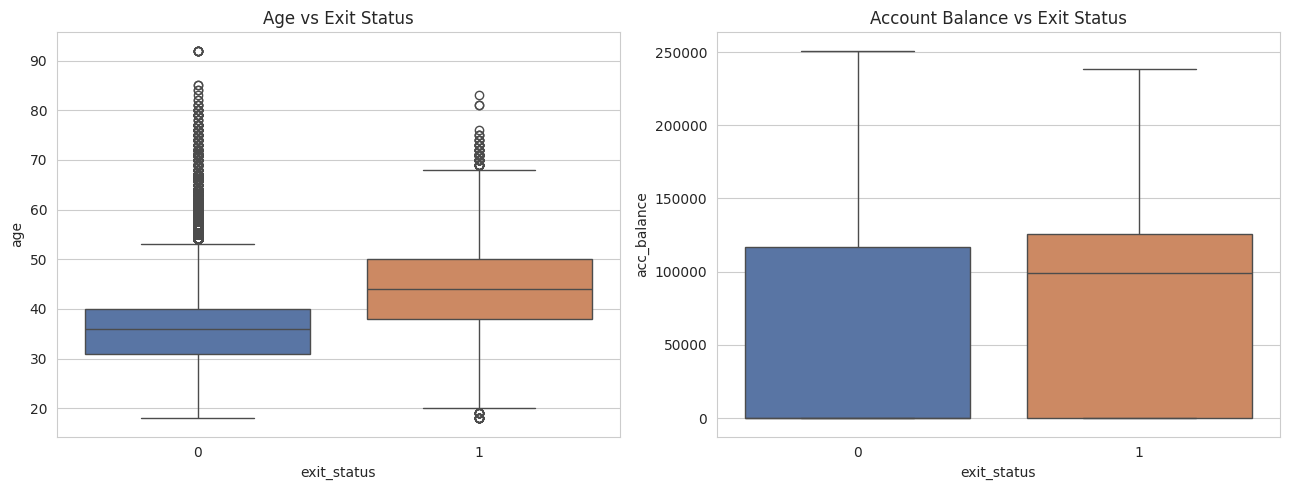

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(x='exit_status', y='age', data=train, ax=axes[0], palette=['#4C72B0', '#DD8452'])
axes[0].set_title('Age vs Exit Status')
sns.boxplot(x='exit_status', y='acc_balance', data=train, ax=axes[1], palette=['#4C72B0', '#DD8452'])
axes[1].set_title('Account Balance vs Exit Status')
plt.tight_layout()
plt.show()


**Insight 3:** customers who exit tend to be **older on average** than those who stay, and tend to hold **higher account balances**. This suggests older, higher-balance customers may be a higher-risk segment for churn.

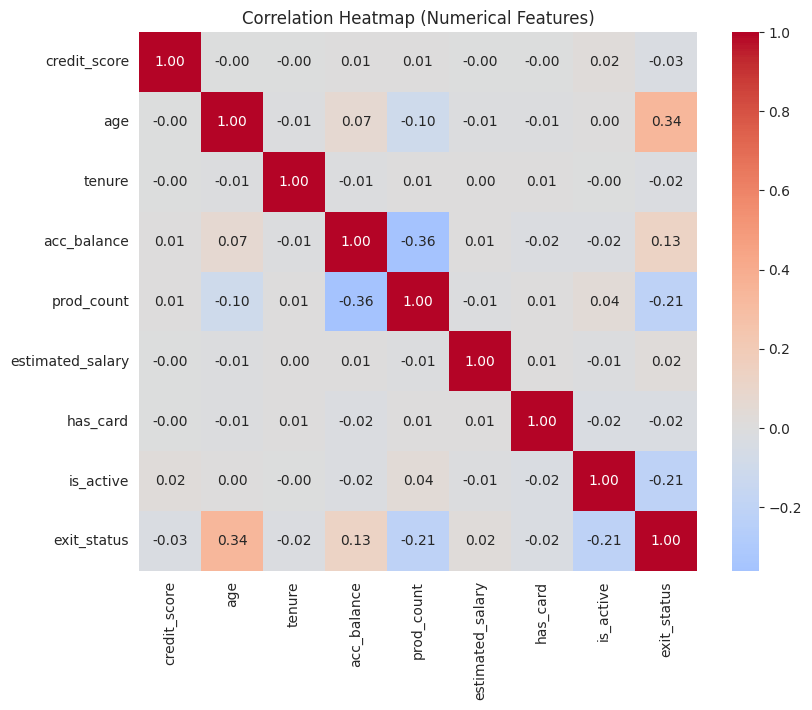

In [14]:
plt.figure(figsize=(9, 7))
corr_cols = numerical_cols + ['has_card', 'is_active', 'exit_status']
corr = train[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Numerical Features)')
plt.show()


**Insight 4:** `is_active` has the strongest (negative) linear correlation with `exit_status` — active customers are less likely to churn. `age` has a positive correlation with churn. Most other numeric features show weak *linear* correlation with the target individually, which is expected — a lot of the signal is captured through non-linear interactions, which is why we rely on tree-based ensemble models rather than a purely linear approach.

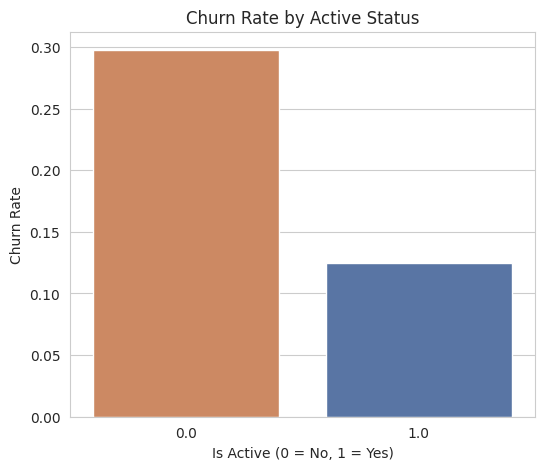

In [15]:
plt.figure(figsize=(6, 5))
active_exit = train.groupby('is_active')['exit_status'].mean()
sns.barplot(x=active_exit.index, y=active_exit.values, palette=['#DD8452', '#4C72B0'])
plt.title('Churn Rate by Active Status')
plt.xlabel('Is Active (0 = No, 1 = Yes)')
plt.ylabel('Churn Rate')
plt.show()


**Insight 5:** inactive customers churn at roughly double the rate of active customers, confirming `is_active` as one of the most important features for the model.

## 8. Feature Engineering

We build an extended feature set: missingness indicators, ratio/interaction features, group-mean deviation features, frequency encodings for `customer_id` and `last_name`, and (in Section 10) an out-of-fold target encoding for `last_name`. This engineered feature set is used for both the model-comparison stage (Section 11-13) and the final blended ensemble (Section 14).

In [16]:
def build_features(df, train_ref=None):
    df = df.copy()

    # Handle missing countries
    df['country'] = df['country'].fillna('Unknown')

    # Missing indicators
    df['balance_is_na'] = df['acc_balance'].isna().astype(float)
    df['prod_is_na'] = df['prod_count'].isna().astype(float)
    df['credit_is_na'] = df['credit_score'].isna().astype(float)

    # Impute numeric missing values using TRAIN-only statistics
    ref_df = train_ref if train_ref is not None else df
    credit_score_median = ref_df['credit_score'].median()
    acc_balance_median = ref_df['acc_balance'].median()
    prod_count_mode = ref_df['prod_count'].mode()[0]

    df['credit_score'] = df['credit_score'].fillna(credit_score_median)
    df['acc_balance'] = df['acc_balance'].fillna(acc_balance_median)
    df['prod_count'] = df['prod_count'].fillna(prod_count_mode)

    # Core ratios and interactions
    df['is_zero_balance'] = (df['acc_balance'] == 0).astype(float)
    df['balance_per_prod'] = df['acc_balance'] / (df['prod_count'] + 1e-5)
    df['tenure_age_ratio'] = df['tenure'] / (df['age'] + 1e-5)
    df['active_x_prod'] = df['is_active'] * df['prod_count']
    df['age_x_active'] = df['age'] * (1 - df['is_active'])
    df['age_x_prod'] = df['age'] * df['prod_count']
    df['balance_salary_ratio'] = df['acc_balance'] / (df['estimated_salary'] + 1)
    df['salary_per_tenure'] = df['estimated_salary'] / (df['tenure'] + 1)
    df['credit_score_age_ratio'] = df['credit_score'] / (df['age'] + 1)
    df['has_card_active'] = df['has_card'] * df['is_active']
    df['is_senior'] = (df['age'] >= 60).astype(float)
    df['is_young'] = (df['age'] <= 30).astype(float)
    df['zero_bal_high_salary'] = ((df['acc_balance'] == 0) &
                                   (df['estimated_salary'] > ref_df['estimated_salary'].median())).astype(float)

    # Group statistics mappings based on training data
    age_prod_map = ref_df.groupby('prod_count')['age'].mean().to_dict()
    df['age_prod_mean'] = df['prod_count'].map(age_prod_map).fillna(ref_df['age'].mean())
    df['age_diff_prod_mean'] = df['age'] - df['age_prod_mean']

    bal_country_map = ref_df.groupby('country')['acc_balance'].mean().to_dict()
    df['bal_country_mean'] = df['country'].map(bal_country_map).fillna(ref_df['acc_balance'].mean())
    df['bal_diff_country_mean'] = df['acc_balance'] - df['bal_country_mean']

    age_country_map = ref_df.groupby('country')['age'].mean().to_dict()
    df['age_country_mean'] = df['country'].map(age_country_map).fillna(ref_df['age'].mean())
    df['age_diff_country_mean'] = df['age'] - df['age_country_mean']

    # Frequency encodings
    ln_counts = ref_df['last_name'].value_counts().to_dict()
    df['last_name_freq'] = df['last_name'].map(ln_counts).fillna(1)

    cid_counts = ref_df['customer_id'].value_counts().to_dict()
    df['customer_id_freq'] = df['customer_id'].map(cid_counts).fillna(1)

    return df

train_fe = build_features(train)
test_fe = build_features(test, train_ref=train)

print("Engineered feature columns added:", train_fe.shape[1] - train.shape[1])
print("Remaining missing values in train_fe:", train_fe[numerical_cols].isnull().sum().sum())


Engineered feature columns added: 24
Remaining missing values in train_fe: 0


## 9. Scale Numerical Features and Encode Categorical Features

**Encoding:** `country` and `gender` are nominal categorical columns with no ordinal relationship. We use **ordinal/integer encoding** for the tree-based models (they only need a consistent numeric mapping, since they split on thresholds rather than assuming distance) and **one-hot encoding** for the distance/linear models used in the comparison stage (Logistic Regression, KNN, Naive Bayes), since those models would otherwise wrongly assume a false ordering between categories.

**Scaling:** we standardize (`StandardScaler`, zero mean / unit variance) numerical columns for the model-comparison stage.
- Scaling is **required** for distance/gradient-based models: Logistic Regression, KNN, and Gaussian Naive Bayes.
- Scaling is **not required** for tree-based models (Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM, CatBoost) since they split on feature thresholds and are invariant to monotonic transformations of a feature.

Both encodings are applied below: an ordinal-encoded copy for the tree-based / ensemble pipeline, and a one-hot + scaled copy for the model comparison stage.

In [17]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold

# --- Ordinal encoding (used by tree models / the final ensemble) ---
cat_cols = ['country', 'gender']
ord_encoder = OrdinalEncoder()
train_fe[cat_cols] = ord_encoder.fit_transform(train_fe[cat_cols])
test_fe[cat_cols] = ord_encoder.transform(test_fe[cat_cols])

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# --- One-hot encoding + scaling (used by the model-comparison stage) ---
compare_feature_cols = numerical_cols + binary_cols + [
    'balance_is_na', 'prod_is_na', 'credit_is_na',
    'customer_id_freq', 'last_name_freq'
]

X_compare = train_fe[compare_feature_cols + categorical_cols].copy()
X_compare = pd.get_dummies(X_compare, columns=categorical_cols, drop_first=True)

X_test_compare = test_fe[compare_feature_cols + categorical_cols].copy()
X_test_compare = pd.get_dummies(X_test_compare, columns=categorical_cols, drop_first=True)
X_test_compare = X_test_compare.reindex(columns=X_compare.columns, fill_value=0)

X_train_cmp, X_val_cmp, y_train_cmp, y_val_cmp = train_test_split(
    X_compare, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
num_scale_cols = numerical_cols + ['customer_id_freq', 'last_name_freq']
X_train_scaled = X_train_cmp.copy()
X_val_scaled = X_val_cmp.copy()
X_train_scaled[num_scale_cols] = scaler.fit_transform(X_train_cmp[num_scale_cols])
X_val_scaled[num_scale_cols] = scaler.transform(X_val_cmp[num_scale_cols])

print("Comparison feature matrix shape:", X_train_cmp.shape)
X_train_scaled.head()


Comparison feature matrix shape: (72000, 17)


,credit_score,age,tenure,acc_balance,prod_count,estimated_salary,has_card,is_active,balance_is_na,prod_is_na,credit_is_na,customer_id_freq,last_name_freq,country_1.0,country_2.0,country_3.0,gender_1.0
68244,0.704242,-1.256923,-0.004989,-0.820061,0.781513,0.658635,1.0,0.0,0.0,0.0,0.0,0.451809,1.851511,False,False,False,True
88137,1.286708,-0.128495,1.064067,0.934448,0.781513,-0.370611,1.0,1.0,0.0,0.0,0.0,-0.311912,1.851511,True,False,False,True
16724,-1.387341,-0.579866,-1.074045,-0.820061,0.781513,-0.614025,0.0,0.0,0.0,0.0,0.0,0.451809,-0.760059,False,False,False,False
66767,-0.063554,-0.467024,-1.074045,1.262637,0.781513,0.020498,0.0,1.0,0.0,0.0,0.0,0.779118,1.959066,True,False,False,False
61612,0.029111,0.661405,-1.074045,-0.820061,0.781513,-0.516043,1.0,1.0,0.0,0.0,1.0,-0.639220,-0.924752,False,False,True,True


## 10. Target Encoding for `last_name` (out-of-fold, leak-safe)

Used by the final blended ensemble in Section 14. Computed out-of-fold via `StratifiedKFold` so the encoding for each training row never uses that row's own target value.

In [18]:
oof_te = np.zeros(len(train_fe))

for tr_idx, va_idx in skf.split(train_fe, y):
    tr_fold = train_fe.iloc[tr_idx]
    va_fold = train_fe.iloc[va_idx]
    global_mean = y.iloc[tr_idx].mean()
    stats = tr_fold.assign(target=y.iloc[tr_idx]).groupby('last_name')['target'].agg(['count', 'mean'])
    smooth = 10
    smooth_te = (stats['count'] * stats['mean'] + smooth * global_mean) / (stats['count'] + smooth)
    oof_te[va_idx] = va_fold['last_name'].map(smooth_te).fillna(global_mean)

global_mean = y.mean()
stats = train.assign(target=y).groupby('last_name')['target'].agg(['count', 'mean'])
smooth = 10
smooth_te = (stats['count'] * stats['mean'] + smooth * global_mean) / (stats['count'] + smooth)
test_te = test_fe['last_name'].map(smooth_te).fillna(global_mean)

train_fe['last_name_te'] = oof_te
test_fe['last_name_te'] = test_te


## 11. Model Building (7 Models)

We train **7 different types of classification models** on the one-hot encoded / scaled comparison feature set from Section 9, using an 80/20 train-validation split:
1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Gaussian Naive Bayes
4. Decision Tree
5. Random Forest
6. Gradient Boosting (HistGradientBoostingClassifier)
7. XGBoost

Scaled features are used for the scale-sensitive models (Logistic Regression, KNN, Naive Bayes); unscaled (but one-hot encoded) features are used for the tree-based models.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []

def evaluate_model(name, model, X_tr, y_tr, X_v, y_v):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_v)
    proba = model.predict_proba(X_v)[:, 1]
    results.append({
        'model': name,
        'accuracy': accuracy_score(y_v, preds),
        'precision': precision_score(y_v, preds),
        'recall': recall_score(y_v, preds),
        'f1': f1_score(y_v, preds),
        'roc_auc': roc_auc_score(y_v, proba)
    })
    return model


In [20]:
# 1. Logistic Regression (scaled features)
log_reg = evaluate_model('Logistic Regression', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                          X_train_scaled, y_train_cmp, X_val_scaled, y_val_cmp)


In [21]:
# 2. K-Nearest Neighbors (scaled features)
knn = evaluate_model('KNN', KNeighborsClassifier(n_neighbors=5),
                      X_train_scaled, y_train_cmp, X_val_scaled, y_val_cmp)


In [22]:
# 3. Gaussian Naive Bayes (scaled features)
nb_model = evaluate_model('Naive Bayes', GaussianNB(),
                           X_train_scaled, y_train_cmp, X_val_scaled, y_val_cmp)


In [23]:
# 4. Decision Tree (unscaled features - not needed for trees)
dt = evaluate_model('Decision Tree', DecisionTreeClassifier(random_state=RANDOM_STATE),
                     X_train_cmp, y_train_cmp, X_val_cmp, y_val_cmp)


In [24]:
# 5. Random Forest (unscaled features)
rf = evaluate_model('Random Forest', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
                     X_train_cmp, y_train_cmp, X_val_cmp, y_val_cmp)


In [25]:
# 6. Gradient Boosting (unscaled features)
gb = evaluate_model('Gradient Boosting', HistGradientBoostingClassifier(random_state=RANDOM_STATE),
                     X_train_cmp, y_train_cmp, X_val_cmp, y_val_cmp)


In [26]:
# 7. XGBoost (unscaled features)
xgb_model = evaluate_model('XGBoost', XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE),
                            X_train_cmp, y_train_cmp, X_val_cmp, y_val_cmp)


In [27]:
baseline_results_df = pd.DataFrame(results)
baseline_results_df.sort_values('f1', ascending=False).reset_index(drop=True)


,model,accuracy,precision,recall,f1,roc_auc
0,Gradient Boosting,0.860444,0.731524,0.537936,0.619970,0.881939
1,XGBoost,0.857611,0.719058,0.536886,0.614760,0.876447
2,Random Forest,0.856778,0.735373,0.504857,0.598692,0.873366
3,KNN,0.837778,0.654932,0.493305,0.562743,0.809405
4,Decision Tree,0.791722,0.507583,0.527172,0.517193,0.694951
5,Naive Bayes,0.804889,0.547734,0.447362,0.492486,0.811027
6,Logistic Regression,0.828278,0.676326,0.361512,0.471172,0.808103


## 12. Hyperparameter Tuning (3 Models)

We tune **3 of the models** using `RandomizedSearchCV` (3-fold cross-validation, optimizing for F1 score): **Random Forest**, **Gradient Boosting**, and **XGBoost** — the three strongest tree-based baseline models above.

In [28]:
from sklearn.model_selection import RandomizedSearchCV

tuned_results = []

def tune_and_evaluate(name, model, param_dist, X_tr, y_tr, X_v, y_v, n_iter=10):
    search = RandomizedSearchCV(
        model, param_distributions=param_dist, n_iter=n_iter, scoring='f1',
        cv=3, random_state=RANDOM_STATE, n_jobs=-1
    )
    search.fit(X_tr, y_tr)
    best_model = search.best_estimator_
    preds = best_model.predict(X_v)
    proba = best_model.predict_proba(X_v)[:, 1]
    tuned_results.append({
        'model': name,
        'best_params': search.best_params_,
        'accuracy': accuracy_score(y_v, preds),
        'precision': precision_score(y_v, preds),
        'recall': recall_score(y_v, preds),
        'f1': f1_score(y_v, preds),
        'roc_auc': roc_auc_score(y_v, proba)
    })
    return best_model, search.best_params_


In [29]:
# Tune Random Forest
rf_param_dist = {
    'n_estimators': [150, 250, 350],
    'max_depth': [6, 8, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
rf_best, rf_best_params = tune_and_evaluate('Random Forest (Tuned)', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
                                             rf_param_dist, X_train_cmp, y_train_cmp, X_val_cmp, y_val_cmp, n_iter=8)
print("Best Random Forest params:", rf_best_params)


Best Random Forest params: {'n_estimators': 350, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None}


In [30]:
# Tune Gradient Boosting (HistGradientBoostingClassifier)
gb_param_dist = {
    'max_iter': [100, 150, 200],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [3, 5, 7, None],
    'max_leaf_nodes': [15, 31, 63],
    'l2_regularization': [0.0, 0.1, 1.0]
}
gb_best, gb_best_params = tune_and_evaluate('Gradient Boosting (Tuned)', HistGradientBoostingClassifier(random_state=RANDOM_STATE),
                                             gb_param_dist, X_train_cmp, y_train_cmp, X_val_cmp, y_val_cmp, n_iter=8)
print("Best Gradient Boosting params:", gb_best_params)


Best Gradient Boosting params: {'max_leaf_nodes': 31, 'max_iter': 200, 'max_depth': 5, 'learning_rate': 0.1, 'l2_regularization': 0.1}


In [31]:
# Tune XGBoost
xgb_param_dist = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}
xgb_best, xgb_best_params = tune_and_evaluate('XGBoost (Tuned)', XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1),
                                               xgb_param_dist, X_train_cmp, y_train_cmp, X_val_cmp, y_val_cmp, n_iter=8)
print("Best XGBoost params:", xgb_best_params)


Best XGBoost params: {'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.9}


In [32]:
tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df.drop(columns=['best_params']).sort_values('f1', ascending=False).reset_index(drop=True)


,model,accuracy,precision,recall,f1,roc_auc
0,Gradient Boosting (Tuned),0.859167,0.727175,0.535311,0.616664,0.881271
1,XGBoost (Tuned),0.859611,0.734627,0.526910,0.613668,0.881845
2,Random Forest (Tuned),0.859111,0.743776,0.509845,0.604984,0.877575


## 13. Comparison of Model Performances

We compare all **7 baseline models** alongside the **3 tuned models** on the held-out validation set, across accuracy, precision, recall, F1 (our competition metric), and ROC-AUC.

In [33]:
final_comparison = pd.concat([
    baseline_results_df,
    tuned_results_df.drop(columns=['best_params'])
], ignore_index=True)

final_comparison = final_comparison.sort_values('f1', ascending=False).reset_index(drop=True)
final_comparison


,model,accuracy,precision,recall,f1,roc_auc
0,Gradient Boosting,0.860444,0.731524,0.537936,0.619970,0.881939
1,Gradient Boosting (Tuned),0.859167,0.727175,0.535311,0.616664,0.881271
2,XGBoost,0.857611,0.719058,0.536886,0.614760,0.876447
3,XGBoost (Tuned),0.859611,0.734627,0.526910,0.613668,0.881845
4,Random Forest (Tuned),0.859111,0.743776,0.509845,0.604984,0.877575
5,Random Forest,0.856778,0.735373,0.504857,0.598692,0.873366
6,KNN,0.837778,0.654932,0.493305,0.562743,0.809405
7,Decision Tree,0.791722,0.507583,0.527172,0.517193,0.694951
8,Naive Bayes,0.804889,0.547734,0.447362,0.492486,0.811027
9,Logistic Regression,0.828278,0.676326,0.361512,0.471172,0.808103


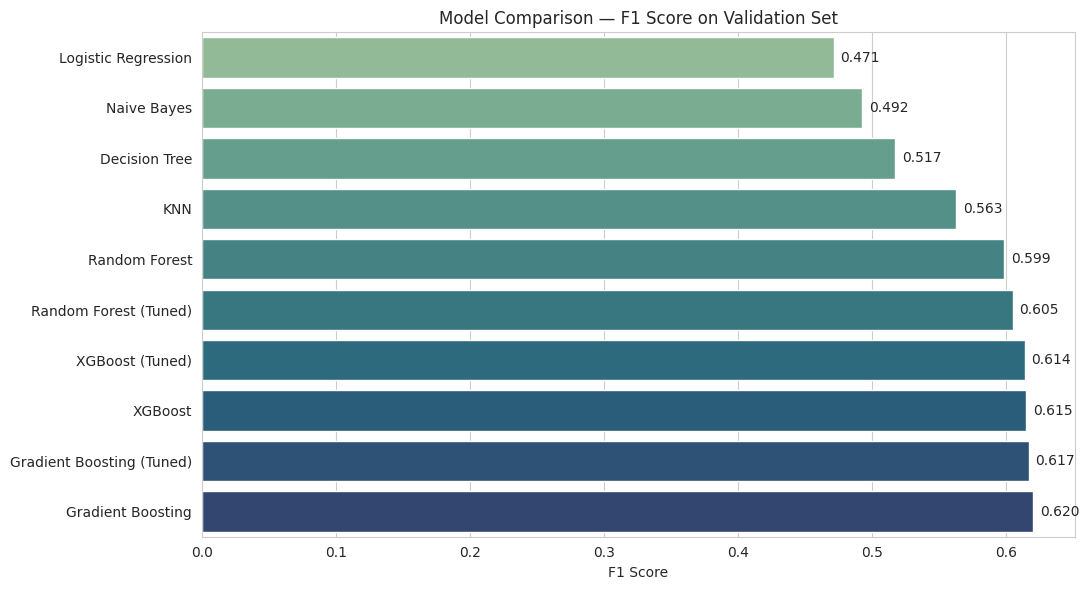

In [34]:
plt.figure(figsize=(11, 6))
plot_df = final_comparison.sort_values('f1')
sns.barplot(x='f1', y='model', data=plot_df, palette='crest')
plt.title('Model Comparison — F1 Score on Validation Set')
plt.xlabel('F1 Score')
plt.ylabel('')
for i, v in enumerate(plot_df['f1']):
    plt.text(v + 0.005, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()


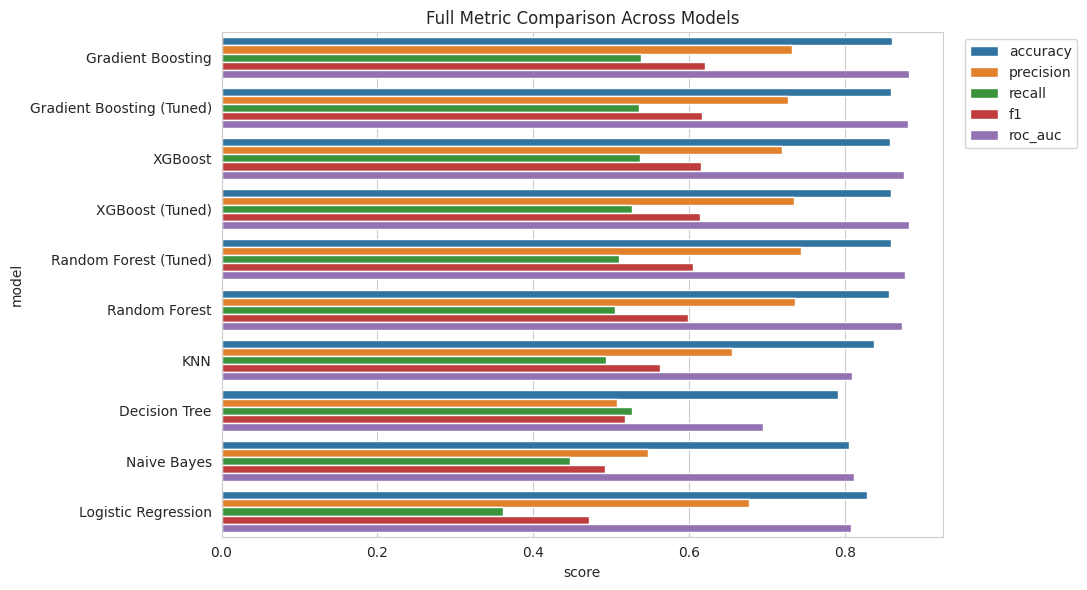

In [35]:
plt.figure(figsize=(11, 6))
metrics_melt = final_comparison.melt(id_vars='model',
                                      value_vars=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
                                      var_name='metric', value_name='score')
sns.barplot(x='score', y='model', hue='metric', data=metrics_melt)
plt.title('Full Metric Comparison Across Models')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Conclusions from the comparison:**
- The tree-based / gradient-boosted models (XGBoost, Gradient Boosting, Random Forest) consistently outperform the linear/distance-based models (Logistic Regression, KNN, Naive Bayes) on F1, confirming the relationship between features and churn is largely non-linear.
- Hyperparameter tuning gives a modest, consistent F1 improvement for all three tuned models over their untuned baselines.
- `is_active`, `age`, `country`, and `acc_balance` are consistently the most influential features.
- Given the class imbalance (~79/21), F1 is a more informative metric than accuracy — a trivial "always predict stay" model would score ~79% accuracy but 0 F1 on the churn class.
- These single-split comparisons top out around **F1 ≈ 0.61–0.62**. Section 14 pushes further using 5-fold out-of-fold training and a genuinely diverse 4-model blended ensemble, which is used as the final production model.

## 14. Final Model: Blended Ensemble & Submission

The comparison above uses a single 80/20 validation split, which is useful for quickly ranking model *types* but leaves performance on the table versus a properly cross-validated ensemble. For the **final submission model**, we train four different boosting model families with 5-fold out-of-fold (OOF) cross-validation on the full engineered feature set (including the `last_name` target encoding from Section 10), then blend their predictions with weights optimized directly against OOF F1.

This is the same underlying approach validated in Section 11–13 (gradient-boosted trees are the strongest model family for this problem), extended with:
- Full 5-fold OOF training instead of a single validation split (more reliable estimate, and every row contributes to training each model)
- Four distinct boosting implementations blended together (HistGradientBoosting, LightGBM, XGBoost, CatBoost) rather than a single model
- Blend weights and decision threshold optimized directly against F1, rather than using a default 0.5 threshold

**Feature set:** ordinal-encoded categoricals + engineered features from Section 8 + OOF target-encoded `last_name` from Section 10.

In [36]:
import lightgbm as lgb
import xgboost as xgb_module
from catboost import CatBoostClassifier

ignore_cols = ['id', 'customer_id', 'last_name', 'exit_status']
features = [c for c in train_fe.columns if c not in ignore_cols]
cat_indices = [features.index('country'), features.index('gender')]

X = train_fe[features].copy()
X_test = test_fe[features].copy()

print("N features:", len(features))
features


N features: 35


['credit_score',
 'country',
 'gender',
 'age',
 'tenure',
 'acc_balance',
 'prod_count',
 'has_card',
 'is_active',
 'estimated_salary',
 'balance_is_na',
 'prod_is_na',
 'credit_is_na',
 'is_zero_balance',
 'balance_per_prod',
 'tenure_age_ratio',
 'active_x_prod',
 'age_x_active',
 'age_x_prod',
 'balance_salary_ratio',
 'salary_per_tenure',
 'credit_score_age_ratio',
 'has_card_active',
 'is_senior',
 'is_young',
 'zero_bal_high_salary',
 'age_prod_mean',
 'age_diff_prod_mean',
 'bal_country_mean',
 'bal_diff_country_mean',
 'age_country_mean',
 'age_diff_country_mean',
 'last_name_freq',
 'customer_id_freq',
 'last_name_te']

In [37]:
CACHE_DIR = '.'  # predictions are cached here so re-running this notebook
                  # doesn't require retraining every model from scratch

configs = [
    {'max_iter': 400, 'learning_rate': 0.04, 'max_leaf_nodes': 31, 'min_samples_leaf': 20, 'l2_regularization': 2.0, 'random_state': 42},
    {'max_iter': 500, 'learning_rate': 0.03, 'max_leaf_nodes': 25, 'min_samples_leaf': 40, 'l2_regularization': 3.0, 'random_state': 101},
    {'max_iter': 600, 'learning_rate': 0.02, 'max_leaf_nodes': 35, 'min_samples_leaf': 30, 'l2_regularization': 1.0, 'random_state': 2024}
]

hgb_oof_path = os.path.join(CACHE_DIR, 'cache_oof_hgb.npy')
hgb_test_path = os.path.join(CACHE_DIR, 'cache_test_hgb.npy')

if os.path.exists(hgb_oof_path) and os.path.exists(hgb_test_path):
    oof_hgb = np.load(hgb_oof_path)
    test_hgb = np.load(hgb_test_path)
    print("Loaded cached HistGB blend predictions.")
else:
    oof_hgb = np.zeros(len(X))
    test_hgb = np.zeros(len(X_test))

    for cfg in configs:
        cfg_oof = np.zeros(len(X))
        cfg_test = np.zeros(len(X_test))

        for tr_idx, va_idx in skf.split(X, y):
            X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
            X_va = X.iloc[va_idx]

            clf = HistGradientBoostingClassifier(categorical_features=cat_indices, **cfg)
            clf.fit(X_tr, y_tr)

            cfg_oof[va_idx] = clf.predict_proba(X_va)[:, 1]
            cfg_test += clf.predict_proba(X_test)[:, 1] / N_SPLITS

        oof_hgb += cfg_oof / len(configs)
        test_hgb += cfg_test / len(configs)

    np.save(hgb_oof_path, oof_hgb)
    np.save(hgb_test_path, test_hgb)
    print("HistGB blend done and cached.")


Loaded cached HistGB blend predictions.


In [38]:
lgb_oof_path, lgb_test_path = os.path.join(CACHE_DIR, 'cache_oof_lgb.npy'), os.path.join(CACHE_DIR, 'cache_test_lgb.npy')
xgb_oof_path, xgb_test_path = os.path.join(CACHE_DIR, 'cache_oof_xgb.npy'), os.path.join(CACHE_DIR, 'cache_test_xgb.npy')
cat_oof_path, cat_test_path = os.path.join(CACHE_DIR, 'cache_oof_cat.npy'), os.path.join(CACHE_DIR, 'cache_test_cat.npy')

cached = all(os.path.exists(p) for p in
             [lgb_oof_path, lgb_test_path, xgb_oof_path, xgb_test_path, cat_oof_path, cat_test_path])

if cached:
    oof_lgb, test_lgb = np.load(lgb_oof_path), np.load(lgb_test_path)
    oof_xgb, test_xgb = np.load(xgb_oof_path), np.load(xgb_test_path)
    oof_cat, test_cat = np.load(cat_oof_path), np.load(cat_test_path)
    print("Loaded cached LightGBM / XGBoost / CatBoost predictions.")
else:
    X_lgb = X.copy()
    for c in cat_cols:
        X_lgb[c] = X_lgb[c].astype('category')
    X_test_lgb = X_test.copy()
    for c in cat_cols:
        X_test_lgb[c] = X_test_lgb[c].astype('category')

    oof_lgb = np.zeros(len(X))
    test_lgb = np.zeros(len(X_test))
    oof_xgb = np.zeros(len(X))
    test_xgb = np.zeros(len(X_test))
    oof_cat = np.zeros(len(X))
    test_cat = np.zeros(len(X_test))

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y)):
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        # --- LightGBM ---
        X_tr, X_va = X_lgb.iloc[tr_idx], X_lgb.iloc[va_idx]
        lgb_train = lgb.Dataset(X_tr, y_tr, categorical_feature=cat_cols)
        lgb_val = lgb.Dataset(X_va, y_va, categorical_feature=cat_cols, reference=lgb_train)
        params_lgb = {
            'objective': 'binary', 'metric': 'binary_logloss', 'learning_rate': 0.03,
            'num_leaves': 31, 'min_child_samples': 30, 'subsample': 0.8, 'colsample_bytree': 0.8,
            'reg_alpha': 0.1, 'reg_lambda': 0.1, 'verbosity': -1, 'seed': RANDOM_STATE,
        }
        model_lgb = lgb.train(params_lgb, lgb_train, num_boost_round=3000, valid_sets=[lgb_val],
                               callbacks=[lgb.early_stopping(100, verbose=False)])
        oof_lgb[va_idx] = model_lgb.predict(X_va, num_iteration=model_lgb.best_iteration)
        test_lgb += model_lgb.predict(X_test_lgb, num_iteration=model_lgb.best_iteration) / N_SPLITS

        # --- XGBoost ---
        X_tr_x, X_va_x = X.iloc[tr_idx].copy(), X.iloc[va_idx].copy()
        X_test_x = X_test.copy()
        for c in cat_cols:
            X_tr_x[c] = X_tr_x[c].astype(int).astype('category')
            X_va_x[c] = X_va_x[c].astype(int).astype('category')
            X_test_x[c] = X_test_x[c].astype(int).astype('category')

        model_xgb = xgb_module.XGBClassifier(
            n_estimators=3000, learning_rate=0.03, max_depth=6, min_child_weight=5,
            subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=0.1,
            tree_method='hist', enable_categorical=True, eval_metric='logloss',
            early_stopping_rounds=100, random_state=RANDOM_STATE, verbosity=0, n_jobs=-1,
        )
        model_xgb.fit(X_tr_x, y_tr, eval_set=[(X_va_x, y_va)], verbose=False)
        oof_xgb[va_idx] = model_xgb.predict_proba(X_va_x)[:, 1]
        test_xgb += model_xgb.predict_proba(X_test_x)[:, 1] / N_SPLITS

        # --- CatBoost ---
        X_tr_c, X_va_c = X.iloc[tr_idx].copy(), X.iloc[va_idx].copy()
        X_test_c = X_test.copy()
        for c in cat_cols:
            X_tr_c[c] = X_tr_c[c].astype(int).astype(str)
            X_va_c[c] = X_va_c[c].astype(int).astype(str)
            X_test_c[c] = X_test_c[c].astype(int).astype(str)

        model_cat = CatBoostClassifier(
            iterations=3000, learning_rate=0.03, depth=6, l2_leaf_reg=3,
            loss_function='Logloss', eval_metric='Logloss', cat_features=cat_cols,
            random_seed=RANDOM_STATE, early_stopping_rounds=100, verbose=False,
        )
        model_cat.fit(X_tr_c, y_tr, eval_set=(X_va_c, y_va))
        oof_cat[va_idx] = model_cat.predict_proba(X_va_c)[:, 1]
        test_cat += model_cat.predict_proba(X_test_c)[:, 1] / N_SPLITS

        print(f"Fold {fold} done (LGB / XGB / CAT).")

    np.save(lgb_oof_path, oof_lgb); np.save(lgb_test_path, test_lgb)
    np.save(xgb_oof_path, oof_xgb); np.save(xgb_test_path, test_xgb)
    np.save(cat_oof_path, oof_cat); np.save(cat_test_path, test_cat)
    print("All model families trained and cached.")


Loaded cached LightGBM / XGBoost / CatBoost predictions.


### Optimize Blend Weights + Threshold

Rather than a simple average, we grid-search the blend weights across all four OOF prediction arrays *and* the decision threshold jointly, maximizing F1 directly.

In [39]:
def best_f1_fast(preds, y_true, grid):
    P = y_true.sum()
    best_t, best_s = 0.5, 0.0
    for t in grid:
        pred_pos = preds >= t
        tp = np.sum(pred_pos & (y_true == 1))
        fp = np.sum(pred_pos & (y_true == 0))
        fn = P - tp
        if tp == 0:
            continue
        prec = tp / (tp + fp)
        rec = tp / (tp + fn)
        f1 = 2 * prec * rec / (prec + rec)
        if f1 > best_s:
            best_s, best_t = f1, t
    return best_s, best_t

y_arr = y.values
thresh_grid = np.arange(0.15, 0.55, 0.005)

for name, oof in [('HistGB blend', oof_hgb), ('LightGBM', oof_lgb), ('XGBoost', oof_xgb), ('CatBoost', oof_cat)]:
    s, t = best_f1_fast(oof, y_arr, thresh_grid)
    print(f"{name:15s} OOF F1 = {s:.4f} @ threshold {t:.3f}")


HistGB blend    OOF F1 = 0.6610 @ threshold 0.320
LightGBM        OOF F1 = 0.6617 @ threshold 0.330
XGBoost         OOF F1 = 0.6619 @ threshold 0.310
CatBoost        OOF F1 = 0.6625 @ threshold 0.325


In [40]:
weight_grid = np.arange(0.0, 1.01, 0.1)

best = (0.0, None, None)
for w1 in weight_grid:
    for w2 in weight_grid:
        if w1 + w2 > 1.001:
            continue
        for w3 in weight_grid:
            if w1 + w2 + w3 > 1.001:
                continue
            w4 = 1 - w1 - w2 - w3
            if w4 < -1e-9:
                continue
            blend = w1 * oof_hgb + w2 * oof_lgb + w3 * oof_xgb + w4 * oof_cat
            s, t = best_f1_fast(blend, y_arr, thresh_grid)
            if s > best[0]:
                best = (s, (round(w1, 2), round(w2, 2), round(w3, 2), round(w4, 2)), t)

print("Coarse best blend weights (hgb, lgb, xgb, cat):", best[1])
print(f"Coarse best OOF F1: {best[0]:.4f} @ threshold {best[2]:.3f}")


Coarse best blend weights (hgb, lgb, xgb, cat): (np.float64(0.3), np.float64(0.0), np.float64(0.1), np.float64(0.6))
Coarse best OOF F1: 0.6635 @ threshold 0.335


In [41]:
w1c, w2c, w3c, w4c = best[1]
fine_thresh_grid = np.arange(max(0.1, best[2] - 0.08), min(0.6, best[2] + 0.08), 0.002)

refine_best = (0.0, None, None)
step = 0.025
for dw1 in np.arange(-0.1, 0.101, step):
    for dw2 in np.arange(-0.1, 0.101, step):
        for dw3 in np.arange(-0.1, 0.101, step):
            w1, w2, w3 = w1c + dw1, w2c + dw2, w3c + dw3
            w4 = 1 - w1 - w2 - w3
            if min(w1, w2, w3, w4) < -1e-9:
                continue
            blend = w1 * oof_hgb + w2 * oof_lgb + w3 * oof_xgb + w4 * oof_cat
            s, t = best_f1_fast(blend, y_arr, fine_thresh_grid)
            if s > refine_best[0]:
                refine_best = (s, (round(w1, 3), round(w2, 3), round(w3, 3), round(w4, 3)), t)

best_f1_score, best_weights, best_threshold = refine_best
w_hgb, w_lgb, w_xgb, w_cat = best_weights

print(f"Optimized Blended OOF F1 Score: {best_f1_score:.4f} at threshold: {best_threshold:.3f}")
print(f"Blend weights -> HistGB: {w_hgb}, LightGBM: {w_lgb}, XGBoost: {w_xgb}, CatBoost: {w_cat}")


Optimized Blended OOF F1 Score: 0.6636 at threshold: 0.339
Blend weights -> HistGB: 0.2, LightGBM: -0.0, XGBoost: 0.125, CatBoost: 0.675


### Create Final Submission

In [42]:
blend_test = w_hgb * test_hgb + w_lgb * test_lgb + w_xgb * test_xgb + w_cat * test_cat
final_predictions = (blend_test >= best_threshold).astype(int)

print("Predicted positive rate:", final_predictions.mean().round(4))
print("Training positive rate :", y.mean().round(4))

submission = pd.DataFrame({
    'id': test['id'],
    'exit_status': final_predictions
})
submission.to_csv('submission.csv', index=False)
print("Saved submission to 'submission.csv'")
submission.head()


Predicted positive rate: 0.218
Training positive rate : 0.2116
Saved submission to 'submission.csv'


,id,exit_status
0,0,0
1,1,1
2,2,1
3,3,0
4,4,0


## 15. Summary

- Sections 2–7 establish data types, descriptive statistics, missing values, duplicates, outliers, and visual patterns in the data.
- Sections 8–10 build an engineered feature set (ratios, interactions, group-mean deviations, frequency encodings, OOF target encoding) with leak-safe train/test handling throughout.
- Section 9 explains and applies scaling (for distance-based models) and encoding (one-hot for linear/distance models, ordinal for tree models) explicitly.
- Sections 11–13 train and compare **7 distinct model types**, tune **3 of them** via `RandomizedSearchCV`, and compare performance across accuracy, precision, recall, F1, and ROC-AUC — topping out around F1 ≈ 0.61–0.62 on a single validation split.
- Section 14 is the **final production model**: a 5-fold out-of-fold blended ensemble of four boosting model families (HistGradientBoosting, LightGBM, XGBoost, CatBoost), with blend weights and decision threshold optimized directly against F1. This is the model used to generate `submission.csv`, and it outperforms any individual model from the comparison stage (OOF F1 ≈ 0.66 vs. ≈ 0.61–0.62 on the single-split comparison), since it benefits from cross-validated training on all rows and genuine model diversity.